# TFG.Geoanálisis de la accesibilidad peatonal a las instalaciones deportivas municipales de Alicante
# Autor Diego Fernández Perales

## 0. Dependencias

In [1]:
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install","osmnx", "geopandas",
                "folium", "alphashape","esda", "libpysal", "statsmodels", "--quiet"],check=False,)

CompletedProcess(args=['C:\\Users\\diego\\anaconda3\\python.exe', '-m', 'pip', 'install', 'osmnx', 'geopandas', 'folium', 'alphashape', 'esda', 'libpysal', 'statsmodels', '--quiet'], returncode=0)

## 1. Imports y configuración

In [2]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import folium
import alphashape
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pathlib import Path
from shapely.geometry import Point
from shapely.ops import unary_union
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess
from libpysal.weights import Queen, lag_spatial
from esda.moran import Moran, Moran_Local, Moran_BV, Moran_Local_BV

from branca.element import MacroElement
from branca.colormap import ColorMap
from jinja2 import Template
from folium.plugins import MiniMap, Fullscreen
from IPython.display import display


CARPETA_INPUTS = Path("inputs")
CARPETA_MAPAS = Path("mapas")
CARPETA_MAPAS.mkdir(exist_ok=True)
CARPETA_VISORES = Path("visores")
CARPETA_VISORES.mkdir(exist_ok=True)
CARPETA_IMAGENES = Path("imagenes")
CARPETA_IMAGENES.mkdir(exist_ok=True)

CENTRO_ALICANTE = [38.3452, -0.4810]
VELOCIDAD_ADULTO = 4.5     
VELOCIDAD_MAYORES = 3.42    
UMBRAL_MINUTOS = 15
RADIO_SEG = UMBRAL_MINUTOS * 60   

colores_categoria = {
    "piscina": "blue",
    "futbol": "darkgreen",
    "polideportivo": "red",
    "voley": "orange",
    "atletismo": "black",
}
iconos_categoria = {
    "polideportivo": ("trophy", colores_categoria["polideportivo"]),
    "futbol": ("futbol", colores_categoria["futbol"]),
    "piscina": ("tint", colores_categoria["piscina"]),
    "zona deportiva playa": ("star", colores_categoria["voley"]),
    "atletismo": ("person-running", colores_categoria["atletismo"]),
}

## Funciones del visor

In [3]:
class BrujulaSVG(MacroElement):
    """Brújula con rosa de los vientos en la esquina superior derecha del visor."""
    def __init__(self):
        super().__init__()
        self._template = Template("""
        {% macro script(this, kwargs) %}
        var northControl = L.control({position: 'topright'});
        northControl.onAdd = function(map) {
            var div = L.DomUtil.create('div');
            div.innerHTML = `
                <svg width="95" height="95" viewBox="0 0 95 95"
                     style="filter: drop-shadow(2px 2px 5px rgba(0,0,0,0.45)); background: rgba(255,255,255,0.94); border-radius:10px; padding:4px;">
                  <circle cx="47.5" cy="47.5" r="44" fill="white" stroke="#2c3e50" stroke-width="2.2"/>
                  <circle cx="47.5" cy="47.5" r="34" fill="none" stroke="#bdc3c7" stroke-width="1"/>
                  <text x="47.5" y="14" text-anchor="middle" fill="#c0392b" font-size="13" font-weight="bold" font-family="Arial">N</text>
                  <text x="47.5" y="89" text-anchor="middle" fill="#2c3e50" font-size="11" font-family="Arial">S</text>
                  <text x="84" y="51" text-anchor="middle" fill="#2c3e50" font-size="11" font-family="Arial">E</text>
                  <text x="11" y="51" text-anchor="middle" fill="#2c3e50" font-size="11" font-family="Arial">O</text>
                  <polygon points="47.5,18 53,47.5 47.5,41 42,47.5" fill="#e74c3c" stroke="#922b21" stroke-width="0.7"/>
                  <polygon points="47.5,77 53,47.5 47.5,54 42,47.5" fill="#95a5a6" stroke="#5d6d7e" stroke-width="0.7"/>
                  <circle cx="47.5" cy="47.5" r="4.2" fill="#2c3e50"/>
                </svg>`;
            return div;
        };
        northControl.addTo({{this._parent.get_name()}});
        {% endmacro %}
        """)
        
def crear_visor(zoom=12, centro=None, tiles="CartoDB positron"):
    """Crea un mapa base de Folium centrado en Alicante."""
    return folium.Map(
        location=centro or CENTRO_ALICANTE,
        zoom_start=zoom,
        tiles=tiles,
        control_scale=True,
    )
    
def titulo_mapa(texto, subtitulo=None):
    bloque_sub = ""
    if subtitulo:
        bloque_sub = f'<div style="font-size:14px; color:#555; margin-top:4px; font-weight:normal;">{subtitulo}</div>'
    return f"""
    <div style="position: fixed; top: 12px; left: 50%; transform: translateX(-50%);
        z-index: 1000; background: rgba(255,255,255,0.96); padding: 12px 22px;
        border-radius: 10px; box-shadow: 2px 2px 10px rgba(0,0,0,0.30);
        font-family: Arial, sans-serif; text-align: center; min-width: 420px;
        max-width: 760px; white-space: normal;">
        <div style="font-size: 18px; font-weight: bold; color: #1f2d3a; line-height: 1.25;">{texto}</div>
        {bloque_sub}
    </div>
    """
    
def pie_cartografico(fuente, datos):
    nota = ("<br><span style='color:#666;'>Sistema de coordenadas de análisis: "
            "ETRS89 / UTM zona 30N (EPSG:25830)</span>")
    return f"""
    <div style="position: fixed; bottom: 10px; left: 50%; transform: translateX(-50%);
        z-index: 1000; background: rgba(255,255,255,0.95); padding: 8px 14px;
        border-radius: 8px; box-shadow: 2px 2px 6px rgba(0,0,0,0.25);
        font-family: Arial, sans-serif; font-size: 11px; color: #444;
        line-height: 1.35; text-align: center; max-width: 620px;">
        <b>Cartografía base:</b> {fuente} ·
        <b>Fuentes:</b> {datos} ·
        <b>Elaboración propia</b>
        {nota}
    </div>
    """

def leyenda_html(titulo, contenido):
    return f"""
    <div style="position: fixed; bottom: 42px; right: 10px; z-index: 1000;
        background: rgba(255,255,255,0.96); padding: 15px 19px; border-radius: 10px;
        box-shadow: 2px 2px 8px rgba(0,0,0,0.30); font-family: Arial, sans-serif;
        font-size: 18px; line-height: 1.50; min-width: 250px; max-width: 340px;">
        <div style="font-size:15px; font-weight:bold; color:#1f2d3a;">{titulo}</div>
        <hr style="margin:7px 0;">
        {contenido}
    </div>
    """
    
def leyenda_instalaciones():
    return f"""
  <hr style="margin:7px 0;">
  <b style="font-size:15px;">Instalaciones deportivas</b><br>
  <span style="color:{colores_categoria['polideportivo']};font-size:16px;">&#9679;</span> Polideportivo / Pabellón<br>
  <span style="color:{colores_categoria['futbol']};font-size:16px;">&#9679;</span> Fútbol / Ciudad Deportiva<br>
  <span style="color:{colores_categoria['piscina']};font-size:16px;">&#9679;</span> Piscina municipal<br>
  <span style="color:{colores_categoria['voley']};font-size:16px;">&#9679;</span> Zona Playa San Juan<br>
  <span style="color:{colores_categoria['atletismo']};font-size:16px;">&#9679;</span> Atletismo<br>
  <hr style="margin:7px 0;">
"""

def cuadros_leyenda(colores_etiquetas):
    """Genera los cuadritos de color + etiqueta de una leyenda a partir de
    una lista de pares (color, etiqueta)."""
    filas = ""
    for color, etiqueta in colores_etiquetas:
        filas += (
            f'<span style="background:{color};display:inline-block;width:14px;height:14px;'
            f'border-radius:2px;margin-right:6px;vertical-align:middle;"></span>{etiqueta}<br>'
        )
    return filas

def añadir_instalaciones(mapa, instalaciones):
    grupo = folium.FeatureGroup(name="Instalaciones deportivas", show=True)
    for _, fila in instalaciones.iterrows():
        categoria = str(fila["categoria"])
        nombre = str(fila["name"])
        icono, color = iconos_categoria.get(categoria, ("map-marker", "gray"))
        folium.Marker(
            location=[fila.geometry.y, fila.geometry.x],
            tooltip=folium.Tooltip(f"<b>{nombre}</b><br><i>{categoria.capitalize()}</i>", sticky=True),
            popup=folium.Popup(f"<b>{nombre}</b><br>{categoria.capitalize()}", max_width=220),
            icon=folium.Icon(color=color, icon_color="white", icon=icono, prefix="fa"),
        ).add_to(grupo)
    grupo.add_to(mapa)

def añadir_barrios(mapa, barrios, etiquetas=True):
    grupo = folium.FeatureGroup(name="Barrios", show=True)
    folium.GeoJson(
        barrios,
        style_function=lambda x: {"fillColor": "transparent", "color": "#111111",
                                  "weight": 1.8, "fillOpacity": 0, "opacity": 0.85},
        highlight_function=lambda x: {"weight": 3.3, "color": "#e74c3c", "opacity": 1.0},
        tooltip=folium.GeoJsonTooltip(fields=["NOMBRE"], aliases=["Barrio:"],
                                      localize=True, style="font-size:14px; font-family:Arial;"),
    ).add_to(grupo)
    if etiquetas:
        for _, fila in barrios.iterrows():
            punto = fila.geometry.representative_point()
            folium.Marker(
                location=[punto.y, punto.x],
                icon=folium.DivIcon(
                    html=f"""<div style="font-size:10px; font-weight:bold; color:#1f1f1f;
                        background:rgba(255,255,255,0.70); padding:2px 4px; border-radius:3px;
                        white-space:nowrap; text-shadow:1px 1px 2px white; pointer-events:none;">{fila["NOMBRE"]}</div>""",
                    icon_size=(1, 1), icon_anchor=(0, 0),
                ),
            ).add_to(grupo)
    grupo.add_to(mapa)


def capa_tooltip(mapa, gdf, fields, aliases, nombre="Detalle por sección censal",
                 style_function=None, show=True):
    if style_function is None:
        style_function = lambda x: {"fillColor": "transparent", "color": "transparent",
                                    "weight": 0, "fillOpacity": 0}
    folium.GeoJson(
        gdf, name=nombre, show=show, style_function=style_function,
        tooltip=folium.GeoJsonTooltip(fields=fields, aliases=aliases, localize=True,
                                      sticky=True, style="font-size:14px; font-family:Arial;"),
    ).add_to(mapa)


def quitar_barra_color(choropleth):
    for clave in list(choropleth._children):
        hijo = choropleth._children[clave]
        if isinstance(hijo, ColorMap) or clave.lower().startswith("color_map"):
            del choropleth._children[clave]
    return choropleth

def capa_coropleta(mapa, gdf, columna, esquema_color, cortes,
                   nombre="Coropleta", show=True):
    coropleta = folium.Choropleth(
        geo_data=gdf, data=gdf, columns=["CUSEC", columna],
        key_on="feature.properties.CUSEC", fill_color=esquema_color,
        fill_opacity=0.75, line_opacity=0.3, bins=cortes,
        nan_fill_color="lightgray", name=nombre, show=show,
    )
    coropleta.add_to(mapa)
    quitar_barra_color(coropleta)
    return coropleta

def capa_categorica(mapa, gdf, campo, colores, tooltip_fields, tooltip_aliases, nombre="Capa"):
    gdf = gdf.copy()
    for col in gdf.select_dtypes(["category"]).columns:
        gdf[col] = gdf[col].astype(str)
    folium.GeoJson(
        gdf, name=nombre, show=True,
        style_function=lambda f: {"fillColor": colores.get(f["properties"].get(campo, ""), "#cccccc"),
                                  "color": "#666666", "weight": 0.4, "fillOpacity": 0.78},
        highlight_function=lambda f: {"weight": 2.2, "color": "#1f2d3a", "fillOpacity": 0.92},
        tooltip=folium.GeoJsonTooltip(fields=tooltip_fields, aliases=tooltip_aliases,
                                      localize=True, sticky=True, style="font-size:13px; font-family:Arial;"),
    ).add_to(mapa)

def finalizar_visor(mapa, titulo=None, subtitulo=None, leyenda=None,
                    fuente_base="CartoDB Positron · OpenStreetMap",
                    fuentes_datos=None):
    if titulo:
        mapa.get_root().html.add_child(folium.Element(titulo_mapa(titulo, subtitulo)))
    if leyenda:
        mapa.get_root().html.add_child(folium.Element(leyenda))
    BrujulaSVG().add_to(mapa)
    if fuentes_datos:
        fuentes_datos= fuentes_datos
    MiniMap(toggle_display=True, position="bottomleft").add_to(mapa)
    Fullscreen(position="topleft").add_to(mapa)
    mapa.get_root().html.add_child(folium.Element(pie_cartografico(fuente_base, fuentes_datos)))
    folium.LayerControl(collapsed=False).add_to(mapa)
    return mapa

## 2. Red viaria peatonal

In [4]:
print("Descargando la red peatonal de Alicante")
red_peatonal = ox.graph_from_place("Alicante, Spain", network_type="walk")
for u, v, k, atributos in red_peatonal.edges(data=True, keys=True):
    atributos["travel_time"] = atributos["length"] / (VELOCIDAD_ADULTO * 1000 / 3600)
tramos_red = ox.graph_to_gdfs(red_peatonal, nodes=False)
print(f"Red lista — Nodos: {red_peatonal.number_of_nodes()} | Tramos: {red_peatonal.number_of_edges()}")

Descargando la red peatonal de Alicante
Red lista — Nodos: 18729 | Tramos: 55514


## 3. Instalaciones deportivas municipales

In [5]:
print("Descarga instalaciones ")
etiquetas_osm = {"leisure": ["sports_centre", "stadium", "swimming_pool"]}
instalaciones_osm = ox.features_from_place("Alicante, Spain", tags=etiquetas_osm)
instalaciones_osm = instalaciones_osm[["name", "leisure", "geometry"]]
print(f"Instalaciones OSM encontradas: {len(instalaciones_osm)}")

renombrar_nombres = {
    "Juan Antonio Samaranch": ("Polideportivo Juan Antonio Samaranch La Cross", "sports_centre"),
    "Campo de Fútbol Municipal Florida-Babel": ("Polideportivo Florida Babel", "sports_centre"),
    "Piscina Municipal Florida-Babel": ("Piscina Municipal Florida-Babel", "swimming_pool"),
    "Pavelló Municipal Florida-Babel Vicente Crespo": ("Pabellón Municipal Florida Babel Vicente Crespo", "sports_centre"),
    "Centre de Tecnificació i Alt Rendiment": ("Centro de Tecnificación de Alicante", "sports_centre"),
    "Polideportivo Municipal Manuel Fuster Ferrándiz": ("Polideportivo Carolinas", "sports_centre"),
    "Centro deportivo Gran Vía": ("Polideportivo del Garbinet", "sports_centre"),
    "Centro Deportivo Tossal": ("Polideportivo Rubén Berenguer Ayala Albufereta", "sports_centre"),
    "Campo de fútbol Divina Pastora": ("Campo de Fútbol Divina Pastora", "sports_centre"),
    "Estadio de Atletismo": ("Estadio de Atletismo Joaquín Villar", "sports_centre"),
    "Estadio Antonio Solana": ("Ciudad Deportiva Antonio Solana", "sports_centre"),
}
nombres_a_mantener = [
    "Ciudad Deportiva Antonio Valls",
    "Pabellón Municipal Central Pitiu Rochel",
    "Pabellón Municipal Rafael Pastor Micó",
    'Complejo de Piscinas Monte Tossal "José Antonio Chicoy',
    "Polideportivo Monte Tossal",
    "Polideportivo de San Blas",
    "Polideportivo Justo Hidalgo Ruiz",
    "Campo de Fútbol El Cabo",
    "Campo de Fútbol Virgen del Remedio Luis Gómez",
    "Polideportivo Carolinas",
    "Polideportivo de Tómbola",
    "Polideportivo Rubén Berenguer Ayala",
    "Polideportivo Vía Parque",
    "Zona Deportiva de la Playa de San Juan",
]


instalaciones_osm["geometry"] = instalaciones_osm.geometry.centroid
instalaciones_osm["name"] = instalaciones_osm["name"].str.strip()
whitelist = list(renombrar_nombres) + nombres_a_mantener
instalaciones_municipales = instalaciones_osm[instalaciones_osm["name"].isin(whitelist)].copy()

for nombre_osm, (nombre_oficial, leisure) in renombrar_nombres.items():
    seleccion = instalaciones_municipales["name"] == nombre_osm
    instalaciones_municipales.loc[seleccion, "name"] = nombre_oficial
    instalaciones_municipales.loc[seleccion, "leisure"] = leisure
print(f"Instalaciones OSM seleccionadas: {len(instalaciones_municipales)}")

faltantes = pd.read_csv(CARPETA_INPUTS / "instalaciones_faltantes.csv", encoding="utf-8")
faltantes_geo = gpd.GeoDataFrame(
    faltantes[["name", "leisure"]],
    geometry=[Point(lon, lat) for lat, lon in zip(faltantes["latitud"], faltantes["longitud"])],
    crs="EPSG:4326",
)

instalaciones = pd.concat( [instalaciones_municipales[["name", "leisure", "geometry"]], 
                            faltantes_geo], ignore_index=True,).drop_duplicates(subset="name", keep="first")


def clasificar_categoria(nombre):
    nombre = nombre.lower()
    if "piscina" in nombre:
        return "piscina"
    if "fútbol" in nombre or "futbol" in nombre:
        return "futbol"
    if "atletismo" in nombre:
        return "atletismo"
    if "voley" in nombre:
        return "zona deportiva playa"
    return "polideportivo"  
    
instalaciones["categoria"] = instalaciones["name"].apply(clasificar_categoria)
print(f"Total instalaciones municipales: {len(instalaciones)}")

Descarga instalaciones 
Instalaciones OSM encontradas: 725
Instalaciones OSM seleccionadas: 18
Total instalaciones municipales: 25


## 4. Secciones censales

In [6]:
ruta_seccionado = (CARPETA_INPUTS / "seccionado_2023" /"España_Seccionado2023_ETRS89H30"/ "SECC_CE_20230101.shp")
seccionado_espana = gpd.read_file(ruta_seccionado)
secciones = seccionado_espana[(seccionado_espana["CPRO"] == "03") & (seccionado_espana["CMUN"] == "014")].to_crs(epsg=4326)
print(f"Secciones censales de Alicante: {len(secciones)}")

Secciones censales de Alicante: 246


## 5. Padrón 2023 y densidad de población

In [7]:
padron = pd.read_csv(CARPETA_INPUTS / "Padron_densidad.csv",
                     sep=";", encoding="utf-8-sig", dtype=str)
padron = padron[
    padron["Municipios"].str.contains("03014") &
    padron["Secciones"].str.strip().ne("") &
    (padron["Año de llegada a España"].str.strip() == "Total") &
    (padron["Sexo"].str.strip() == "Total") &
    (padron["Periodo"].str.strip() == "2023")
]
padron["CUSEC"] = padron["Secciones"].str.strip().str[:10]

padron["poblacion"] = pd.to_numeric( padron["Total"].str.replace(".", "", regex=False), errors="coerce")
secciones = secciones.merge(padron[["CUSEC", "poblacion"]], on="CUSEC", how="left")


secciones_utm = secciones.to_crs(epsg=25830)
secciones["area_km2"] = secciones_utm.geometry.area / 1e6
secciones["densidad_hab_km2"] = secciones["poblacion"] / secciones["area_km2"]
poblacion_municipal = secciones["poblacion"].sum()
area_municipal = secciones["area_km2"].sum()

print(f"Población total municipal: {poblacion_municipal:,.0f} hab")
print(f"Área total municipal:      {area_municipal:.1f} km²")
print(f"Densidad municipal:        {poblacion_municipal / area_municipal:.0f} hab/km²")

Población total municipal: 350,598 hab
Área total municipal:      201.4 km²
Densidad municipal:        1741 hab/km²


## 6. Renta por sección censal

In [8]:

renta = pd.read_csv(CARPETA_INPUTS /"30824.csv", sep=";", encoding="latin1", dtype=str)
renta.columns = ["municipio", "distrito", "seccion", "indicador", "periodo", "valor"]
renta = renta[
    renta["municipio"].str.startswith("03014") &
    (renta["indicador"] == "Renta neta media por persona") &
    renta["seccion"].notna()
]
renta["CUSEC"] = renta["seccion"].str[:10]
renta["periodo"] = renta["periodo"].astype(int)
renta["valor"] = (renta["valor"].str.replace(".", "", regex=False)
                                 .str.replace(",", ".", regex=False))
renta["valor"] = pd.to_numeric(renta["valor"], errors="coerce")

renta_2023 = renta[renta["periodo"] == 2023][["CUSEC", "valor"]].rename(columns={"valor": "renta_2023"})
renta_2022 = renta[renta["periodo"] == 2022][["CUSEC", "valor"]].rename(columns={"valor": "renta_2022"})

secciones = secciones.merge(renta_2023, on="CUSEC", how="left").merge(renta_2022, on="CUSEC", how="left")
secciones["renta"] = secciones["renta_2023"].fillna(secciones["renta_2022"])
secciones["fuente_renta"] = np.where(secciones["renta_2023"].notna(), "2023", "2022 (imputado)")
secciones = secciones.drop(columns=["renta_2023", "renta_2022"])
sin_2023 = (secciones["fuente_renta"] == "2022 (imputado)").sum()


## 7. Barrios

In [9]:
barrios = gpd.read_file(CARPETA_INPUTS / "barrios_alicante.geojson").to_crs(epsg=4326)
print(f"Número de barrios: {len(barrios)}")

Número de barrios: 54


## 8. Estructura  demográfica por edad

In [10]:
edades = pd.read_csv(CARPETA_INPUTS / "edades_2023.csv",
                    sep=";", encoding="utf-8-sig", dtype=str)
edades.columns = edades.columns.str.strip()
edades = edades.rename(columns={"Secciones": "seccion", "Sexo": "sexo",
                                "Edad": "edad", "Periodo": "anio", "Total": "total"})
edades = edades[
    (edades["anio"].str.strip() == "2023") &
    (edades["sexo"].str.strip() == "Total") &
    edades["Municipios"].str.strip().str.startswith("03014") &
    (edades["seccion"].str.strip().str.len() > 10)
].copy()
edades["CUSEC"] = edades["seccion"].str.extract(r"(\d{10})")
edades["total"] = (edades["total"].str.replace(".", "", regex=False)
                                  .str.replace(",", ".", regex=False))
edades["total"] = pd.to_numeric(edades["total"], errors="coerce")


def edad_minima(grupo):
    grupo = grupo.strip()
    if "Todas" in grupo:
        return np.nan
    if "100" in grupo or "más" in grupo.lower():
        return 100
    numeros = re.findall(r"\d+", grupo)
    return int(numeros[0]) if numeros else np.nan


edades["edad_min"] = edades["edad"].apply(edad_minima)
edades = edades.dropna(subset=["CUSEC", "edad_min", "total"])


def poblacion_por_rango(edad_desde, edad_hasta):
    rango = edades[edades["edad_min"].between(edad_desde, edad_hasta)]
    return rango.groupby("CUSEC")["total"].sum()


demografia = pd.concat([
    edades.groupby("CUSEC")["total"].sum().rename("pob_total"),
    poblacion_por_rango(0, 14).rename("pob_menores_15"),
    poblacion_por_rango(65, 100).rename("pob_mayores_65"),
], axis=1).fillna(0)
demografia["pct_menores_15"] = (demografia["pob_menores_15"] / demografia["pob_total"] * 100).round(2)
demografia["pct_mayores_65"] = (demografia["pob_mayores_65"] / demografia["pob_total"] * 100).round(2)
secciones = secciones.merge(demografia.reset_index(), on="CUSEC", how="left")

print(f"Población total (por edades): {demografia['pob_total'].sum():,.0f} hab")
print(f"Menores de 15: {demografia['pob_menores_15'].sum():,.0f} "
      f"({demografia['pob_menores_15'].sum() / demografia['pob_total'].sum() * 100:.1f}%)")
print(f"Mayores de 65: {demografia['pob_mayores_65'].sum():,.0f} "
      f"({demografia['pob_mayores_65'].sum() / demografia['pob_total'].sum() * 100:.1f}%)")


def normalizar_0_1(serie):
    """Escala una serie al rango [0, 1]."""
    return (serie - serie.min()) / (serie.max() - serie.min())

Población total (por edades): 350,598 hab
Menores de 15: 48,451 (13.8%)
Mayores de 65: 68,852 (19.6%)


# 9. Resultados y visualización cartográfica

## 9.1 Instalaciones deportivas

In [11]:
visor_instalaciones = crear_visor(zoom=13)
añadir_instalaciones(visor_instalaciones, instalaciones)
añadir_barrios(visor_instalaciones, barrios)

leyenda = leyenda_html("Instalaciones deportivas municipales", leyenda_instalaciones())
finalizar_visor(
    visor_instalaciones,
    titulo="Instalaciones deportivas municipales — Alicante",
    leyenda=leyenda,
    fuentes_datos="Ayuntamiento de Alicante · OpenStreetMap · Elaboración propia",
)
visor_instalaciones.save("mapas/visor_instalaciones.html")
print("Visor de instalaciones guardado")

instalaciones = gpd.sjoin(instalaciones, barrios[["NOMBRE", "geometry"]],
                          how="left", predicate="intersects")

tabla_instalaciones = instalaciones[["name", "categoria", "NOMBRE"]].copy()
tabla_instalaciones.columns = ["Nombre", "Categoría", "Barrio"]
tabla_instalaciones = tabla_instalaciones.reset_index(drop=True)
tabla_instalaciones.index += 1
#display(tabla_instalaciones)


resumen_categorias = instalaciones["categoria"].value_counts()
#plt.figure(figsize=(9, 5))
#plt.barh(resumen_categorias.index, resumen_categorias.values)
#plt.xlabel("Número de instalaciones")
#plt.ylabel("Categoría")
#plt.title("Instalaciones deportivas municipales por categoría")
#plt.tight_layout()
#plt.show()

Visor de instalaciones guardado


### 9.1 Visor mapas

#### Visor peatonal

In [12]:
visor_red = crear_visor(zoom=13)
grupo_red = folium.FeatureGroup(name="Red peatonal", show=True)
for geometria in tramos_red.geometry:
    if geometria.geom_type == "LineString":
        coords = [(lat, lon) for lon, lat in geometria.coords]
        folium.PolyLine(coords, weight=1.5, color="#1a6eb5", opacity=0.6).add_to(grupo_red)
grupo_red.add_to(visor_red)
finalizar_visor(
    visor_red,
    titulo="Red peatonal utilizada para el análisis de accesibilidad",
    subtitulo="Municipio de Alicante",
    leyenda=leyenda_html("Red peatonal", '<span style="color:#1a6eb5;">━━</span> Tramos de la red peatonal'),
    fuentes_datos="OpenStreetMap · OSMnx · Elaboración propia",
)
visor_red.save("visores/visor_red_peatonal.html")
print("Visor de la red peatonal guardado")

Visor de la red peatonal guardado


#### Visor secciones

In [13]:
visor_secciones = crear_visor(zoom=12)
capa_tooltip(
    visor_secciones, secciones,
    fields=["CUSEC", "CDIS"], aliases=["Sección:", "Distrito:"],
    nombre="Secciones censales",
    style_function=lambda x: {"fillColor": "transparent", "color": "#c0392b",
                              "weight": 1.2, "opacity": 0.6, "fillOpacity": 0},
)
añadir_instalaciones(visor_secciones, instalaciones)
añadir_barrios(visor_secciones, barrios)
finalizar_visor(visor_secciones, 
                titulo="Secciones censales e instalaciones — Alicante" , 
                fuentes_datos="INE · Ayuntamiento de Alicante · OpenStreetMap",)
visor_secciones.save("visores/visor_secciones.html")
print("Visor de secciones guardado")

Visor de secciones guardado


In [14]:
#densidad = secciones[secciones["densidad_hab_km2"] > 0]
#cortes_densidad = [0] + list(densidad["densidad_hab_km2"].quantile([0.2, 0.4, 0.6, 0.8])) + \
#                  [densidad["densidad_hab_km2"].max() + 1]
#etiquetas_densidad = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
#colores_densidad = ["#ffffcc", "#a1dab4", "#41b6c4", "#2c7fb8", "#253494"]

#secciones["cat_densidad"] = pd.cut(secciones["densidad_hab_km2"], bins=cortes_densidad,
#                                   labels=etiquetas_densidad, include_lowest=True).astype(str)

#visor_densidad = crear_visor(zoom=13)
#mapa_color_densidad = dict(zip(etiquetas_densidad, colores_densidad))
#capa_categorica(
#    visor_densidad, secciones, "cat_densidad", mapa_color_densidad,
#    tooltip_fields=["CUSEC", "cat_densidad", "densidad_hab_km2", "poblacion", "area_km2"],
#    tooltip_aliases=["Sección:", "Categoría:", "Densidad (hab/km²):", "Población:", "Área (km²):"],
#    nombre="Densidad de población",
#)
#leyenda = leyenda_html(
#    "Densidad de población (hab/km²)",
#    '<i style="color:gray;font-size:12px;">Quintiles · Padrón 2023</i><hr style="margin:5px 0;">'
#    + cuadros_leyenda(list(zip(colores_densidad, etiquetas_densidad))),
#)
#finalizar_visor(visor_densidad, titulo="Densidad de población por sección censal — Alicante 2023",
#                leyenda=leyenda, fuentes_datos="INE Padrón 2023 · OSM · Ayuntamiento de Alicante")
#visor_densidad.save("visor/visor_densidad.html")
#print("Visor de densidad guardado")

#### Visor rentas

In [15]:
cortes_renta = list(secciones["renta"].dropna().quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]))
cortes_renta[0] -= 0.001
cortes_renta[-1] += 0.001

visor_renta = crear_visor(zoom=13)
capa_coropleta(visor_renta, secciones, "renta", "RdYlGn", cortes_renta, nombre="Renta media por sección")
capa_tooltip(visor_renta, secciones,
             fields=["CUSEC", "renta", "fuente_renta"],
             aliases=["Sección:", "Renta media (€):", "Fuente:"],
             nombre="Detalle por sección (renta)")

colores_renta = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]
etiquetas_renta = ["Renta alta", "Renta media-alta", "Renta media", "Renta media-baja", "Renta baja"]
rangos_renta = [(cortes_renta[i + 1], cortes_renta[i]) for i in range(4, -1, -1)]
items_renta = [(color, f"{etiqueta} ({inf:,.0f}€–{sup:,.0f}€)")
               for color, etiqueta, (sup, inf) in zip(colores_renta, etiquetas_renta, rangos_renta)]
leyenda = leyenda_html(
    "Renta neta media por persona (€)",
    cuadros_leyenda(items_renta) +
    '<small style="color:#888;font-size:12px;">* secciones sin dato 2023 imputadas con 2022</small>',
)
añadir_barrios(visor_renta, barrios)
finalizar_visor(visor_renta, titulo="Renta neta media por sección censal — Alicante 2023",
                leyenda=leyenda, fuentes_datos="INE · Atlas de Distribución de Renta · OSM")

visor_renta.save("visores/visor_renta.html")
print("Visor de renta guardado")

Visor de renta guardado


## 9.2 Accesibilidad

In [16]:
nodo_instalacion = [ox.nearest_nodes(red_peatonal, p.x, p.y) for p in instalaciones.geometry]
nodo_seccion = [ox.nearest_nodes(red_peatonal, s.representative_point().x, s.representative_point().y)
                for s in secciones.geometry]
print(f"Nodos calculados: {len(nodo_instalacion)} instalaciones · {len(nodo_seccion)} secciones")

Nodos calculados: 25 instalaciones · 246 secciones


### 9.2.1 Isócronas de cobertura

In [17]:
tiempos_isocrona = [10 * 60, 15 * 60, 20 * 60]
poligonos_isocrona = {t: [] for t in tiempos_isocrona}

print("Calculando isócronas...")
for nodo in nodo_instalacion:
    for t in tiempos_isocrona:
        subgrafo = nx.ego_graph(red_peatonal, nodo, radius=t, distance="travel_time")
        nodos_sub = ox.graph_to_gdfs(subgrafo, edges=False)
        if len(nodos_sub) >= 4:
            coords = np.array([(p.x, p.y) for p in nodos_sub.geometry])
            area = alphashape.alphashape(coords, alpha=500)
            if not area.is_empty:
                poligonos_isocrona[t].append(area)

municipio = secciones.union_all()

print("\n[ COBERTURA TERRITORIAL ]")
for t in tiempos_isocrona:
    union = unary_union(poligonos_isocrona[t])
    cobertura = union.intersection(municipio).area / municipio.area * 100
    print(f"  {t // 60:2d} min: {cobertura:.1f}% del territorio")

print("\n[ COBERTURA POBLACIONAL ]")
poblacion_total = secciones["poblacion"].sum()
for t in tiempos_isocrona:
    union = unary_union(poligonos_isocrona[t])
    dentro = secciones[secciones.geometry.representative_point().within(union)]
    print(f"  {t // 60:2d} min: {dentro['poblacion'].sum():,.0f} hab "
          f"({dentro['poblacion'].sum() / poblacion_total * 100:.1f}%)")

Calculando isócronas...

[ COBERTURA TERRITORIAL ]
  10 min: 5.9% del territorio
  15 min: 9.7% del territorio
  20 min: 12.8% del territorio

[ COBERTURA POBLACIONAL ]
  10 min: 180,112 hab (51.4%)
  15 min: 264,201 hab (75.4%)
  20 min: 298,289 hab (85.1%)


In [18]:
#colores_isocrona = {10 * 60: "#2ecc71", 15 * 60: "#f39c12", 20 * 60: "#e74c3c"}
#etiquetas_isocrona = {10 * 60: "10 min", 15 * 60: "15 min", 20 * 60: "20 min"}
#
#fig, ax = plt.subplots(figsize=(12, 12))
#secciones.plot(ax=ax, color="#f5f5f5", edgecolor="white", linewidth=0.4, zorder=1)
#for t in reversed(tiempos_isocrona):
#    union = unary_union(poligonos_isocrona[t])
#    gpd.GeoSeries([union], crs="EPSG:4326").plot(
#        ax=ax, color=colores_isocrona[t], alpha=0.35,
#        edgecolor=colores_isocrona[t], linewidth=0.5, zorder=2)
#instalaciones.plot(ax=ax, color="black", markersize=15, marker="^", zorder=3)

#leyenda_iso = [mpatches.Patch(color=colores_isocrona[t], alpha=0.5, label=etiquetas_isocrona[t])
#               for t in tiempos_isocrona]
#leyenda_iso.append(plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="black",
#                              markersize=8, label="Instalación deportiva"))
#ax.legend(handles=leyenda_iso, loc="lower right", fontsize=10, framealpha=0.9)
#ax.set_axis_off()
#ax.set_title("Áreas de cobertura peatonal por isócronas\nAlicante 2023", fontsize=13)
#plt.tight_layout()
#plt.savefig("imagenes/isocronas.png", dpi=150, bbox_inches="tight")
#plt.show()

#### Visor Isocronas

In [19]:
colores_isocrona = {10 * 60: "#2ecc71", 15 * 60: "#f39c12", 20 * 60: "#e74c3c"}
etiquetas_isocrona = {10 * 60: "10 min", 15 * 60: "15 min", 20 * 60: "20 min"}
visor_isocronas = crear_visor(zoom=13)
grupo_sin = folium.FeatureGroup(name="Sin cobertura (>20 min)", show=True)
folium.GeoJson(secciones, style_function=lambda x: {"fillColor": "#95a5a6", "color": "white",
               "weight": 0.3, "fillOpacity": 0.25, "opacity": 0.5}).add_to(grupo_sin)
grupo_sin.add_to(visor_isocronas)

for t in reversed(tiempos_isocrona):
    union = unary_union(poligonos_isocrona[t])
    grupo = folium.FeatureGroup(name=f"Isócrona {t // 60} min", show=True)
    folium.GeoJson(union.__geo_interface__,
                   style_function=lambda x, c=colores_isocrona[t]: {
                       "fillColor": c, "color": c, "weight": 1,
                       "fillOpacity": 0.35, "opacity": 0.7}).add_to(grupo)
    grupo.add_to(visor_isocronas)

añadir_instalaciones(visor_isocronas, instalaciones)
añadir_barrios(visor_isocronas, barrios)
finalizar_visor(visor_isocronas, titulo="Áreas de cobertura peatonal por isócronas — Alicante 2023",
                fuentes_datos="OSM · Ayuntamiento de Alicante")
visor_isocronas.save("visores/visor_isocronas.html")
print("Visor de isócronas guardado")

Visor de isócronas guardado


### 9.2.2 Tiempo mínimo por sección

Calculando el tiempo mínimo por sección...
  Sección 246/246
[ TIEMPO MÍNIMO POR RED PEATONAL (min) ]
count    246.0
mean      13.6
std       20.5
min        0.9
10%        4.1
25%        6.3
50%        9.4
75%       13.7
90%       20.8
max      182.7
Name: tiempo_min_red, dtype: float64

Umbral de referencia: 15 minutos
  Dentro: 195 secciones · 273,157 hab (77.9%)
  Fuera:  51 secciones · 77,441 hab (22.1%)

[ DISTRIBUCIÓN POR CATEGORÍA ]
cat_accesibilidad
Muy alta (0–5 min)    37
Alta (5–10 min)       97
Media (10–15 min)     61
Baja (15–20 min)      22
Muy baja (>20 min)    29


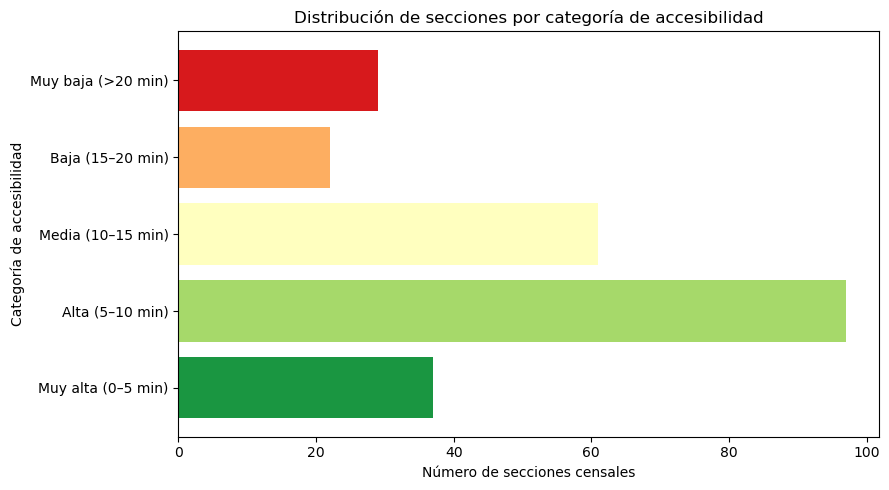

In [20]:
print("Calculando el tiempo mínimo por sección...")
tiempo_min = []
for i, origen in enumerate(nodo_seccion):
    mejor = np.inf
    for destino in nodo_instalacion:
        t = nx.shortest_path_length(red_peatonal, origen, destino, weight="travel_time")
        mejor = min(mejor, t)
    tiempo_min.append(round(mejor / 60, 1) if np.isfinite(mejor) else np.nan)
    print(f"  Sección {i+1}/{len(nodo_seccion)}", end="\r", flush=True)
secciones["tiempo_min_red"] = tiempo_min

dentro_umbral = (secciones["tiempo_min_red"] <= UMBRAL_MINUTOS).sum()
fuera_umbral = (secciones["tiempo_min_red"] > UMBRAL_MINUTOS).sum()
pob_dentro = secciones.loc[secciones["tiempo_min_red"] <= UMBRAL_MINUTOS, "poblacion"].sum()
pob_fuera = poblacion_total - pob_dentro

print("\n[ TIEMPO MÍNIMO POR RED PEATONAL (min) ]")
print(secciones["tiempo_min_red"].describe(percentiles=[.1, .25, .5, .75, .9]).round(1))
print(f"\nUmbral de referencia: {UMBRAL_MINUTOS} minutos")
print(f"  Dentro: {dentro_umbral} secciones · {pob_dentro:,.0f} hab "
      f"({pob_dentro / poblacion_total * 100:.1f}%)")
print(f"  Fuera:  {fuera_umbral} secciones · {pob_fuera:,.0f} hab "
      f"({pob_fuera / poblacion_total * 100:.1f}%)")

etiquetas_acc = ["Muy alta (0–5 min)", "Alta (5–10 min)", "Media (10–15 min)",
                 "Baja (15–20 min)", "Muy baja (>20 min)"]
colores_acc = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]
secciones["cat_accesibilidad"] = pd.cut(secciones["tiempo_min_red"], bins=[0, 5, 10, 15, 20, np.inf], labels=etiquetas_acc)
conteo_acc = secciones["cat_accesibilidad"].value_counts().reindex(etiquetas_acc)
print("\n[ DISTRIBUCIÓN POR CATEGORÍA ]")
print(conteo_acc.to_string())
plt.figure(figsize=(9, 5))
plt.barh(etiquetas_acc, conteo_acc.values, color=colores_acc)
plt.xlabel("Número de secciones censales")
plt.ylabel("Categoría de accesibilidad")
plt.title("Distribución de secciones por categoría de accesibilidad")
plt.tight_layout()
plt.show()

#### Visor Tiempo mínimo 

In [21]:
cortes_tiempo = [-0.01, 5, 10, 15, 20, secciones["tiempo_min_red"].max() + 0.01]

visor_tiempo = crear_visor(zoom=12)
capa_coropleta(visor_tiempo, secciones, "tiempo_min_red", "RdYlGn_r", cortes_tiempo,
               nombre="Tiempo mínimo por red")
capa_tooltip(visor_tiempo, secciones,
             fields=["CUSEC", "tiempo_min_red", "cat_accesibilidad"],
             aliases=["Sección:", "Tiempo mínimo (min):", "Categoría:"],
             nombre="Detalle por sección (tiempo)")
añadir_instalaciones(visor_tiempo, instalaciones)
añadir_barrios(visor_tiempo, barrios)

leyenda = leyenda_html(
    "Accesibilidad peatonal básica",
    '<i style="color:gray;font-size:12px;">Tiempo a la instalación más cercana · 4,5 km/h</i>'
    '<hr style="margin:5px 0;">' + cuadros_leyenda(list(zip(colores_acc, etiquetas_acc))) +
    f'<hr style="margin:5px 0;"><b>Umbral de referencia: {UMBRAL_MINUTOS} minutos</b>'
    + leyenda_instalaciones(),
)
finalizar_visor(visor_tiempo,
                titulo="Accesibilidad peatonal por sección censal — Tiempo mínimo de acceso",
                leyenda=leyenda, fuentes_datos="OSM · INE 2023 · Ayuntamiento de Alicante")
visor_tiempo.save("visores/visor_tiempo_minimo.html")
print("Visor de tiempo mínimo guardado")

Visor de tiempo mínimo guardado


### 9.2.3 Método 2SFCA 

In [22]:
poblacion_seccion = secciones["poblacion"].fillna(0).to_numpy()

print("2SFCA Calculando ratio oferta/demanda")
ratios_oferta = []
for k, nodo_inst in enumerate(nodo_instalacion):
    demanda = 0.0
    for i, nodo_sec in enumerate(nodo_seccion):
        try:
            t = nx.shortest_path_length(red_peatonal, nodo_inst, nodo_sec, weight="travel_time")
        except nx.NetworkXNoPath:
            continue
        if t <= RADIO_SEG:
            demanda += poblacion_seccion[i]
    ratios_oferta.append(1.0 / demanda if demanda > 0 else 0.0)
    print(f"  Instalación {k+1}/{len(nodo_instalacion)}", end="\r", flush=True)

print("2SFCA Calculando Accesibilidad por seccion")
indice_2sfca = []
for k, nodo_sec in enumerate(nodo_seccion):
    acc = 0.0
    for j, nodo_inst in enumerate(nodo_instalacion):
        try:
            t = nx.shortest_path_length(red_peatonal, nodo_sec, nodo_inst, weight="travel_time")
        except nx.NetworkXNoPath:
            continue
        if t <= RADIO_SEG:
            acc += ratios_oferta[j]
    indice_2sfca.append(acc)
    print(f"  Sección {k+1}/{len(nodo_seccion)}", end="\r", flush=True)
secciones["indice_2sfca"] = indice_2sfca
print(f"Secciones sin cobertura (idx = 0): {(secciones['indice_2sfca'] == 0).sum()}")

2SFCA Calculando ratio oferta/demanda
2SFCA Calculando Accesibilidad por seccion
Secciones sin cobertura (idx = 0): 51


#### Visor 2SFCA

In [23]:
con_cobertura = secciones[secciones["indice_2sfca"] > 0]["indice_2sfca"]
cuantiles = con_cobertura.quantile([0.2, 0.4, 0.6, 0.8]).tolist()
maximo_2sfca = secciones["indice_2sfca"].max()
cortes_2sfca = [-1e-10, 0] + cuantiles + [maximo_2sfca + 1e-10]
clases_2sfca = ["sin_cob", "q1", "q2", "q3", "q4", "q5"]
secciones["cat_2sfca"] = pd.cut(secciones["indice_2sfca"], bins=cortes_2sfca, labels=clases_2sfca)

colores_2sfca = ["#d7191c", "#ffffd4", "#c7e9b4", "#7fcdbb", "#2c7fb8", "#253494"]
etiquetas_2sfca = [
    "0.000000 (sin cobertura)",
    f"0.000001 – {cuantiles[0]:.6f}",
    f"{cuantiles[0]:.6f} – {cuantiles[1]:.6f}",
    f"{cuantiles[1]:.6f} – {cuantiles[2]:.6f}",
    f"{cuantiles[2]:.6f} – {cuantiles[3]:.6f}",
    f"{cuantiles[3]:.6f} – {maximo_2sfca:.6f}",
]
mapa_color_2sfca = dict(zip(clases_2sfca, colores_2sfca))
visor_2sfca = crear_visor(zoom=12)
secciones["indice_2sfca_tooltip"] = (secciones["indice_2sfca"] * 1000).round(4)
capa_tooltip(visor_2sfca, secciones,
             fields=["CUSEC", "indice_2sfca_tooltip", "cat_2sfca"],
             aliases=["Sección:", "Índice 2SFCA (×10³):", "Categoría:"],
             nombre="Detalle por sección (2SFCA)",
             style_function=lambda x: {
                 "fillColor": mapa_color_2sfca.get(x["properties"]["cat_2sfca"], "gray"),
                 "color": "white", "weight": 0.5, "fillOpacity": 0.75})
añadir_instalaciones(visor_2sfca, instalaciones)
añadir_barrios(visor_2sfca, barrios)
leyenda = leyenda_html(
    "Accesibilidad potencial 2SFCA",
    '<i style="color:gray;font-size:12px;">Radio 15 min · 4,5 km/h </i><hr style="margin:5px 0;">'
    + cuadros_leyenda(list(zip(colores_2sfca, etiquetas_2sfca))) + leyenda_instalaciones(),
)
finalizar_visor(visor_2sfca, titulo="Accesibilidad potencial 2SFCA — Alicante 2023",
                leyenda=leyenda, fuentes_datos="OSM · INE 2023 · Ayuntamiento de Alicante")
visor_2sfca.save("visores/visor_2sfca.html")
print("Visor 2SFCA guardado")

Visor 2SFCA guardado


In [24]:
#colores_plot = secciones["cat_2sfca"].astype(str).map(mapa_color_2sfca).fillna("gray")
#fig, ax = plt.subplots(figsize=(10, 10))
#secciones.plot(ax=ax, color=colores_plot, edgecolor="white", linewidth=0.4)
#parches = [mpatches.Patch(color=c, label=e) for c, e in zip(colores_2sfca, etiquetas_2sfca)]
#ax.legend(handles=parches, loc="lower right", fontsize=8, framealpha=0.9, title="Accesibilidad 2SFCA")
#ax.set_title("Accesibilidad potencial 2SFCA — Alicante 2023", fontsize=13)
#ax.set_axis_off()
#fig.text(0.5, 0.02, "Fuente: OSM · INE 2023 · Elaboración propia", ha="center", fontsize=9, color="gray")
#plt.tight_layout()
#plt.savefig("mapas/visor_2sfca.png", dpi=200, bbox_inches="tight")
#plt.show()

## 2SFCA mayores 65

In [25]:
for u, v, k, atributos in red_peatonal.edges(data=True, keys=True):
    atributos["travel_time_mayores"] = atributos["length"] / (VELOCIDAD_MAYORES * 1000 / 3600)

pob_mayores = secciones["pob_mayores_65"].fillna(0).to_numpy()
pob_no_mayores = (secciones["poblacion"].fillna(0) - secciones["pob_mayores_65"].fillna(0)).clip(lower=0).to_numpy()

print("2SFCA >65. Calculando ratio oferta/demanda")
ratios_oferta_mov = []
for k, nodo_inst in enumerate(nodo_instalacion):
    demanda = 0.0
    for i, nodo_sec in enumerate(nodo_seccion):
        try:
            t_may = nx.shortest_path_length(red_peatonal, nodo_inst, nodo_sec, weight="travel_time_mayores")
            if t_may <= RADIO_SEG:
                demanda += pob_mayores[i]
        except nx.NetworkXNoPath:
            pass
        try:
            t_resto = nx.shortest_path_length(red_peatonal, nodo_inst, nodo_sec, weight="travel_time")
            if t_resto <= RADIO_SEG:
                demanda += pob_no_mayores[i]
        except nx.NetworkXNoPath:
            pass
    ratios_oferta_mov.append(1.0 / demanda if demanda > 0 else 0.0)
    print(f"  Instalación {k+1}/{len(nodo_instalacion)}", end="\r", flush=True)

print("\n2SFCA >65 Calculando accesibilidad")
indice_2sfca_mayores = []
for k, nodo_sec in enumerate(nodo_seccion):
    acc = 0.0
    for j, nodo_inst in enumerate(nodo_instalacion):
        try:
            t = nx.shortest_path_length(red_peatonal, nodo_sec, nodo_inst, weight="travel_time_mayores")
        except nx.NetworkXNoPath:
            continue
        if t <= RADIO_SEG:
            acc += ratios_oferta_mov[j]
    indice_2sfca_mayores.append(acc)
    print(f"  Sección {k+1}/{len(nodo_seccion)}", end="\r", flush=True)

secciones["indice_2sfca_mayores"] = indice_2sfca_mayores
print(f"\n[ 2SFCA SENIOR ]")
print(secciones["indice_2sfca_mayores"].describe(percentiles=[.1, .25, .5, .75, .9]).round(6))
sin_acceso = secciones[secciones["indice_2sfca_mayores"] == 0]
print(f"Mayores en secciones sin acceso a su velocidad: {sin_acceso['pob_mayores_65'].sum():,.0f} "
      f"({sin_acceso['pob_mayores_65'].sum() / secciones['pob_mayores_65'].sum() * 100:.1f}%)")

2SFCA >65. Calculando ratio oferta/demanda
  Instalación 25/25
2SFCA >65 Calculando accesibilidad
  Sección 246/246
[ 2SFCA SENIOR ]
count    246.000000
mean       0.000041
std        0.000053
min        0.000000
10%        0.000000
25%        0.000000
50%        0.000024
75%        0.000057
90%        0.000105
max        0.000303
Name: indice_2sfca_mayores, dtype: float64
Mayores en secciones sin acceso a su velocidad: 24,212 (35.2%)


## 9.3 Vulnerabilidad de renta

Spearman (todas):       rho = -0.3226  p = 0.0000  n = 246
Spearman (2SFCA > 0):   rho = 0.0263  p = 0.7152  n = 195


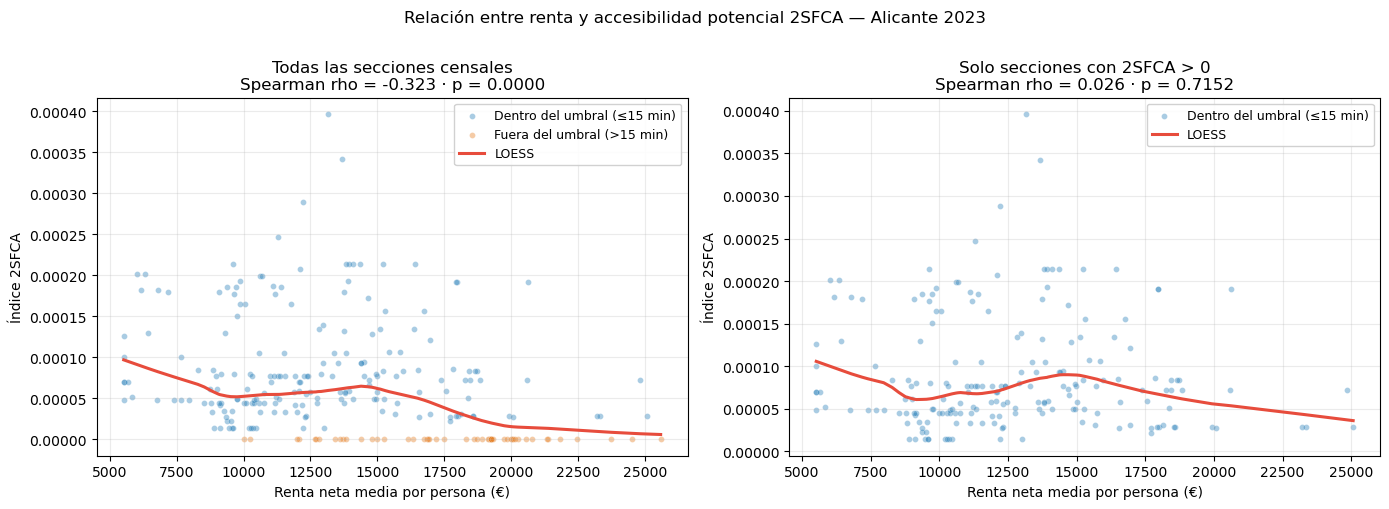

In [26]:
datos = secciones.dropna(subset=["renta", "indice_2sfca"]).copy()
datos["grupo_umbral"] = np.where(datos["tiempo_min_red"] <= UMBRAL_MINUTOS, "Dentro del umbral (≤15 min)", "Fuera del umbral (>15 min)")
con_cobertura = datos[datos["indice_2sfca"] > 0]

rho_todas, p_todas = stats.spearmanr(datos["renta"], datos["indice_2sfca"])
rho_cob, p_cob = stats.spearmanr(con_cobertura["renta"], con_cobertura["indice_2sfca"])
print(f"Spearman (todas):       rho = {rho_todas:.4f}  p = {p_todas:.4f}  n = {len(datos)}")
print(f"Spearman (2SFCA > 0):   rho = {rho_cob:.4f}  p = {p_cob:.4f}  n = {len(con_cobertura)}")


loess_todas = lowess(datos["indice_2sfca"], datos["renta"], frac=0.4, it=3, return_sorted=True)
loess_cob = lowess(con_cobertura["indice_2sfca"], con_cobertura["renta"], frac=0.4, it=3, return_sorted=True)
colores_grupo = {"Dentro del umbral (≤15 min)": "#2980b9", "Fuera del umbral (>15 min)": "#e67e22"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, tabla, suave, titulo, rho, p in [
    (ax1, datos, loess_todas, "Todas las secciones censales", rho_todas, p_todas),
    (ax2, con_cobertura, loess_cob, "Solo secciones con 2SFCA > 0", rho_cob, p_cob)]:
    for grupo, sub in tabla.groupby("grupo_umbral"):
        ax.scatter(sub["renta"], sub["indice_2sfca"], alpha=0.4, s=18,
                   color=colores_grupo[grupo], edgecolors="white", linewidth=0.3, label=grupo)
    ax.plot(suave[:, 0], suave[:, 1], color="#e74c3c", linewidth=2.2, label="LOESS")
    ax.set_xlabel("Renta neta media por persona (€)")
    ax.set_ylabel("Índice 2SFCA")
    ax.set_title(f"{titulo}\nSpearman rho = {rho:.3f} · p = {p:.4f}")
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(alpha=0.25)
plt.suptitle("Relación entre renta y accesibilidad potencial 2SFCA — Alicante 2023", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("imagenes/loess_renta_2sfca.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
COLORES_LISA = {"Alto-Alto": "#d7191c", "Bajo-Bajo": "#2c7bb6", "Alto-Bajo": "#fdae61",
                "Bajo-Alto": "#abd9e9", "No significativo": "#eeeeee"}
NOMBRES_CUADRANTE = {1: "Alto-Alto", 2: "Bajo-Alto", 3: "Bajo-Bajo", 4: "Alto-Bajo"}


def estandarizar(serie):
    return (serie - serie.mean()) / serie.std()


secciones_lisa = secciones.dropna(subset=["indice_2sfca", "renta", "pob_total"]).reset_index(drop=True)
pesos = Queen.from_dataframe(secciones_lisa, silence_warnings=True)
pesos.transform = "r"
acc_z = estandarizar(secciones_lisa["indice_2sfca"]).to_numpy()
renta_z = estandarizar(secciones_lisa["renta"]).to_numpy()

moran_bv = Moran_BV(acc_z, renta_z, pesos)
print(f"[ MORAN BIVARIANTE ] I = {moran_bv.I:.4f} · p = {moran_bv.p_sim:.4f}")

lisa_bv = Moran_Local_BV(acc_z, renta_z, pesos, seed=42)
secciones_lisa["lisa_tipo"] = [
    NOMBRES_CUADRANTE[q] if sig else "No significativo"
    for q, sig in zip(lisa_bv.q, lisa_bv.p_sim < 0.05)]
secciones_lisa["color"] = secciones_lisa["lisa_tipo"].map(COLORES_LISA)
n_significativas = (lisa_bv.p_sim < 0.05).sum()
print(f"[ LISA ] Secciones significativas: {n_significativas}")
print(secciones_lisa[secciones_lisa["lisa_tipo"] != "No significativo"]["lisa_tipo"].value_counts().to_string())

[ MORAN BIVARIANTE ] I = -0.2449 · p = 0.0010
[ LISA ] Secciones significativas: 113
lisa_tipo
Bajo-Alto    40
Bajo-Bajo    34
Alto-Bajo    23
Alto-Alto    16


Visor LISA bivariante guardado


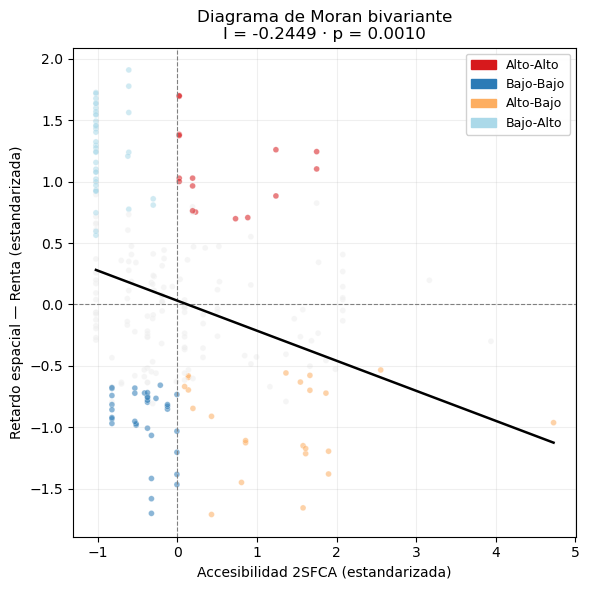

In [28]:
visor_lisa_bv = crear_visor(zoom=12)
secciones_lisa["indice_2sfca_tooltip"] = (secciones_lisa["indice_2sfca"] * 1000).round(4)
folium.GeoJson(
    secciones_lisa[["geometry", "CUSEC", "lisa_tipo", "color", "indice_2sfca_tooltip", "renta"]],
    name="LISA bivariante", show=True,
    style_function=lambda f: {"fillColor": f["properties"]["color"], "color": "#555555",
                              "weight": 0.4, "fillOpacity": 0.80},
    highlight_function=lambda f: {"weight": 2.2, "color": "#1f2d3a", "fillOpacity": 0.95},
    tooltip=folium.GeoJsonTooltip(fields=["CUSEC", "lisa_tipo", "indice_2sfca_tooltip", "renta"],
                                  aliases=["Sección:", "Clúster:", "2SFCA (×10³):", "Renta (€):"],
                                  localize=True, sticky=True, style="font-size:13px; font-family:Arial;"),
).add_to(visor_lisa_bv)
añadir_barrios(visor_lisa_bv, barrios)
items_lisa = "".join(
    f'<div style="margin:3px 0;"><span style="background:{c};display:inline-block;width:14px;height:14px;'
    f'border-radius:2px;vertical-align:middle;margin-right:7px;"></span>{k}</div>'
    for k, c in COLORES_LISA.items())
finalizar_visor(
    visor_lisa_bv, titulo="LISA bivariante — Accesibilidad 2SFCA × Renta",
    subtitulo=f"I = {moran_bv.I:.4f} · p = {moran_bv.p_sim:.4f} · "
              f"Significativas: {n_significativas} secc. · Alicante 2023",
    leyenda=leyenda_html("Clústeres LISA bivariante", items_lisa),
    fuentes_datos="INE Atlas Renta · INE Padrón 2023 · OSM")
visor_lisa_bv.save("visores/visor_lisa_bv.html")
print("Visor LISA bivariante guardado")

retardo_renta = lag_spatial(pesos, renta_z)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(acc_z, retardo_renta, c=secciones_lisa["color"], alpha=0.55, s=18,
           edgecolors="white", linewidth=0.3)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
pendiente, ordenada, *_ = stats.linregress(acc_z, retardo_renta)
recta_x = np.linspace(acc_z.min(), acc_z.max(), 100)
ax.plot(recta_x, pendiente * recta_x + ordenada, color="black", linewidth=1.8)
ax.set_xlabel("Accesibilidad 2SFCA (estandarizada)")
ax.set_ylabel("Retardo espacial — Renta (estandarizada)")
ax.set_title(f"Diagrama de Moran bivariante\nI = {moran_bv.I:.4f} · p = {moran_bv.p_sim:.4f}")
parches = [mpatches.Patch(color=c, label=k) for k, c in COLORES_LISA.items() if k != "No significativo"]
ax.legend(handles=parches, fontsize=9, framealpha=0.9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("imagenes/moran_bv.png", dpi=150, bbox_inches="tight")
plt.show()

## 9.4 Índices de Prioridad Territorial por grupos vulnerables

In [29]:
print("Calculo Indice de Prioridad Territorial.")
secciones["acc_senior_norm"]   = normalizar_0_1(secciones["indice_2sfca_mayores"])
secciones["acc_general_norm"]  = normalizar_0_1(secciones["indice_2sfca"])

secciones["IPT_senior"]   = ((1 - secciones["acc_senior_norm"]) *
                              (secciones["pob_mayores_65"] / secciones["pob_total"]))
secciones["IPT_infantil"] = ((1 - secciones["acc_general_norm"]) *
                              (secciones["pob_menores_15"] / secciones["pob_total"]))

secciones["IPT_senior_norm"]   = normalizar_0_1(secciones["IPT_senior"])
secciones["IPT_infantil_norm"] = normalizar_0_1(secciones["IPT_infantil"])
secciones["renta_inv_norm"]    = 1 - normalizar_0_1(secciones["renta"])

escenarios = {
    "equitativo":       (1/3, 1/3, 1/3),
    "enfasis_senior":   (0.50, 0.25, 0.25),
    "enfasis_infantil": (0.25, 0.50, 0.25),
    "enfasis_renta":    (0.25, 0.25, 0.50),
}
for nombre, (w_sen, w_inf, w_renta) in escenarios.items():
    secciones[f"IPT_sint_{nombre}"] = (
        w_sen   * secciones["IPT_senior_norm"] +
        w_inf   * secciones["IPT_infantil_norm"] +
        w_renta * secciones["renta_inv_norm"]  
    ).round(6)

secciones["IPT_sint"] = secciones["IPT_sint_equitativo"]

Calculo Indice de Prioridad Territorial.


In [30]:
COLORES_QUINTIL = {
    "Q1 baja": "#2166ac",
    "Q2":      "#92c5de",
    "Q3":      "#f7f7f7",
    "Q4":      "#f4a582",
    "Q5 alta": "#d6604d",
}
ETIQUETAS_QUINTIL = {
    "Q1 baja": "Q1 – Baja vulnerabilidad",
    "Q2":      "Q2",
    "Q3":      "Q3 – Media",
    "Q4":      "Q4",
    "Q5 alta": "Q5 – Alta vulnerabilidad",
}
ETIQUETAS_ESCENARIO = {
    "equitativo":       "Base — equilibrio (1/3 · 1/3 · 1/3)",
    "enfasis_senior":   "Senior dominante (1/2 · 1/4 · 1/4)",
    "enfasis_infantil": "Infantil dominante (1/4 · 1/2 · 1/4)",
    "enfasis_renta":    "Renta dominante (1/4 · 1/4 · 1/2)",
}

for nombre, (w_sen, w_inf, w_renta) in escenarios.items():
    col_ipt = f"IPT_sint_{nombre}"
    col_q   = f"quintil_sint_{nombre}"

    secciones[col_q] = pd.qcut(
        secciones[col_ipt], q=5,
        labels=["Q1 baja", "Q2", "Q3", "Q4", "Q5 alta"]
    )

    filas_leyenda = ""
    for cat in ["Q1 baja", "Q2", "Q3", "Q4", "Q5 alta"]:
        c    = COLORES_QUINTIL[cat]
        lab  = ETIQUETAS_QUINTIL[cat]
        secs = (secciones[col_q] == cat).sum()
        pob  = secciones[secciones[col_q] == cat]["pob_total"].sum()
        filas_leyenda += (
            f'<div style="margin:3px 0;">'
            f'<span style="background:{c};display:inline-block;width:14px;'
            f'height:14px;border-radius:2px;vertical-align:middle;'
            f'margin-right:7px;"></span>'
            f'{lab} — {secs} secc. · {pob:,.0f} hab</div>'
        )

    m = crear_visor(zoom=12)
    capa_categorica(
        m, secciones,
        campo=col_q,
        colores=COLORES_QUINTIL,
        tooltip_fields=["CUSEC", col_q, col_ipt,
                        "IPT_senior_norm", "IPT_infantil_norm",
                        "renta_inv_norm", "renta", "pob_total"],
        tooltip_aliases=["Sección:", "Quintil:", "IPT sintético:",
                         "IPT Senior (norm):", "IPT Infantil (norm):",
                         "Vulnerabilidad renta:", "Renta media (€):",
                         "Pob. total:"],
        nombre=f"IPT — {ETIQUETAS_ESCENARIO[nombre]}",
    )
    añadir_barrios(m, barrios)
    finalizar_visor(
        m,
        titulo=f"IPT Sintético — {ETIQUETAS_ESCENARIO[nombre]}",
        subtitulo=f"w_senior={w_sen:.2f} · w_infantil={w_inf:.2f} · w_renta={w_renta:.2f} · Alicante 2023",
        leyenda=leyenda_html(
            f"IPT — {nombre}",
            filas_leyenda +
            "<hr style='margin:6px 0;'>"
            f"<small style='color:#666;'>"
            f"w_senior={w_sen:.2f} · w_infantil={w_inf:.2f} · w_renta={w_renta:.2f}</small>"
        ),
        fuentes_datos="INE Padrón 2023 · INE Atlas Renta · OSM",
    )
    fichero = f"visores/visor_ipt_{nombre}.html"
    m.save(fichero)
    print(f"✓ {nombre:<22} guardado: {fichero}")
    
quintil_superior = {}
for nombre in escenarios:
    col_q = f"quintil_sint_{nombre}"
    quintil_superior[nombre] = set(secciones.loc[secciones[col_q] == "Q5 alta", "CUSEC"])

prioritarias = set.intersection(*quintil_superior.values())
pob_prioritaria = secciones.loc[secciones["CUSEC"].isin(prioritarias), "pob_total"].sum()

print(f"\n[ SECCIONES PRIORITARIAS ROBUSTAS ]")
print(f"  Q5 en los 4 escenarios: {len(prioritarias)} secciones · {pob_prioritaria:,.0f} hab")
print(f"  CUSECs: {sorted(prioritarias)}")

✓ equitativo             guardado: visores/visor_ipt_equitativo.html
✓ enfasis_senior         guardado: visores/visor_ipt_enfasis_senior.html
✓ enfasis_infantil       guardado: visores/visor_ipt_enfasis_infantil.html
✓ enfasis_renta          guardado: visores/visor_ipt_enfasis_renta.html

[ SECCIONES PRIORITARIAS ROBUSTAS ]
  Q5 en los 4 escenarios: 12 secciones · 16,139 hab
  CUSECs: ['0301403004', '0301403009', '0301403012', '0301403031', '0301403032', '0301404007', '0301404009', '0301404013', '0301404015', '0301404025', '0301405005', '0301408006']


## 9.5 Autocorrelación espacial de la accesibilidad


In [31]:
secciones_moran = secciones.dropna(subset=["indice_2sfca"]).reset_index(drop=True)
pesos_acc = Queen.from_dataframe(secciones_moran, silence_warnings=True)
pesos_acc.transform = "r"
valores = secciones_moran["indice_2sfca"].to_numpy()

moran = Moran(valores, pesos_acc)
print(f"[ MORAN GLOBAL ] I = {moran.I:.4f} · p = {moran.p_sim:.4f} · z = {moran.z_norm:.4f}")

lisa = Moran_Local(valores, pesos_acc, seed=42)
secciones_moran["lisa_tipo"] = [
    NOMBRES_CUADRANTE[q] if sig else "No significativo"
    for q, sig in zip(lisa.q, lisa.p_sim < 0.05)]
secciones_moran["color"] = secciones_moran["lisa_tipo"].map(COLORES_LISA)
n_sig = (lisa.p_sim < 0.05).sum()
print(f"[ LISA ] Secciones significativas: {n_sig} ({n_sig / len(secciones_moran) * 100:.1f}%)")
print(secciones_moran[secciones_moran["lisa_tipo"] != "No significativo"]["lisa_tipo"].value_counts().to_string())

[ MORAN GLOBAL ] I = 0.6484 · p = 0.0010 · z = 17.1897
[ LISA ] Secciones significativas: 92 (37.4%)
lisa_tipo
Bajo-Bajo    51
Alto-Alto    36
Bajo-Alto     5


In [32]:
visor_lisa = crear_visor(zoom=12)
secciones_moran["indice_2sfca_tooltip"] = (secciones_moran["indice_2sfca"] * 1000).round(4)
folium.GeoJson(
    secciones_moran[["geometry", "CUSEC", "lisa_tipo", "color", "indice_2sfca_tooltip"]],
    name="LISA accesibilidad 2SFCA", show=True,
    style_function=lambda f: {"fillColor": f["properties"]["color"], "color": "#555555",
                              "weight": 0.4, "fillOpacity": 0.80},
    highlight_function=lambda f: {"weight": 2.2, "color": "#1f2d3a", "fillOpacity": 0.95},
    tooltip=folium.GeoJsonTooltip(fields=["CUSEC", "lisa_tipo", "indice_2sfca_tooltip"],
                                  aliases=["Sección:", "Clúster:", "Índice 2SFCA (×10³):"],
                                  localize=True, sticky=True, style="font-size:13px; font-family:Arial;"),
).add_to(visor_lisa)
añadir_barrios(visor_lisa, barrios)
items_lisa = "".join(
    f'<div style="margin:3px 0;"><span style="background:{c};display:inline-block;width:14px;height:14px;'
    f'border-radius:2px;vertical-align:middle;margin-right:7px;"></span>{k}</div>'
    for k, c in COLORES_LISA.items())
finalizar_visor(
    visor_lisa, titulo="Clústeres LISA — Accesibilidad 2SFCA",
    subtitulo=f"I = {moran.I:.4f} · p = {moran.p_sim:.4f} · {n_sig} secciones significativas · Alicante 2023",
    leyenda=leyenda_html("Clústeres LISA", items_lisa),
    fuentes_datos="INE Padrón 2023 · OSM")
visor_lisa.save("visores/visor_lisa.html")
print("Visor LISA de accesibilidad guardado")

Visor LISA de accesibilidad guardado
